### Import Libraries

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt

In [5]:
import warnings 
warnings.filterwarnings('ignore')

### Data Loading and Cleaning 

In [6]:
df = pd.read_csv(r'shopping_behavior_updated.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [8]:
df['Customer ID'].value_counts()

Customer ID
1       1
2621    1
2593    1
2594    1
2595    1
       ..
1305    1
1306    1
1307    1
1308    1
3900    1
Name: count, Length: 3900, dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.sample(2)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
958,959,70,Male,Sneakers,Footwear,53,Washington,XL,Beige,Winter,4.4,Yes,Free Shipping,Yes,Yes,31,Credit Card,Bi-Weekly
421,422,38,Male,Shirt,Clothing,40,Kentucky,M,Violet,Winter,3.5,Yes,Standard,Yes,Yes,48,Cash,Bi-Weekly


In [12]:
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

#### Univariate Analysis

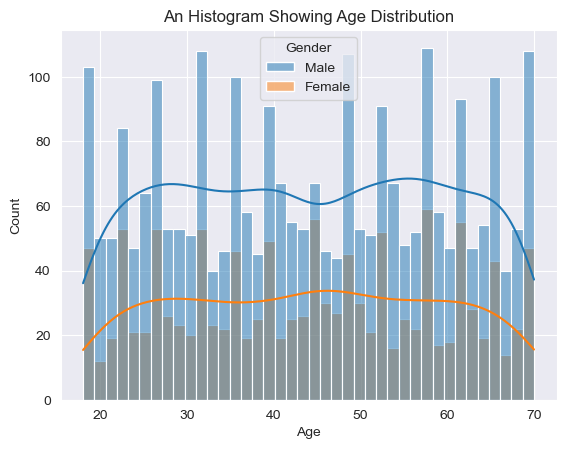

In [13]:
sns.set_style('darkgrid')
sns.histplot(x = 'Age', hue = 'Gender', data =df, kde = True, bins = 40)
plt.title('An Histogram Showing Age Distribution')
plt.show()

##### __Renaming some features__

In [14]:
df.rename(columns = {'Item Purchased': 'Item'}, inplace = True)

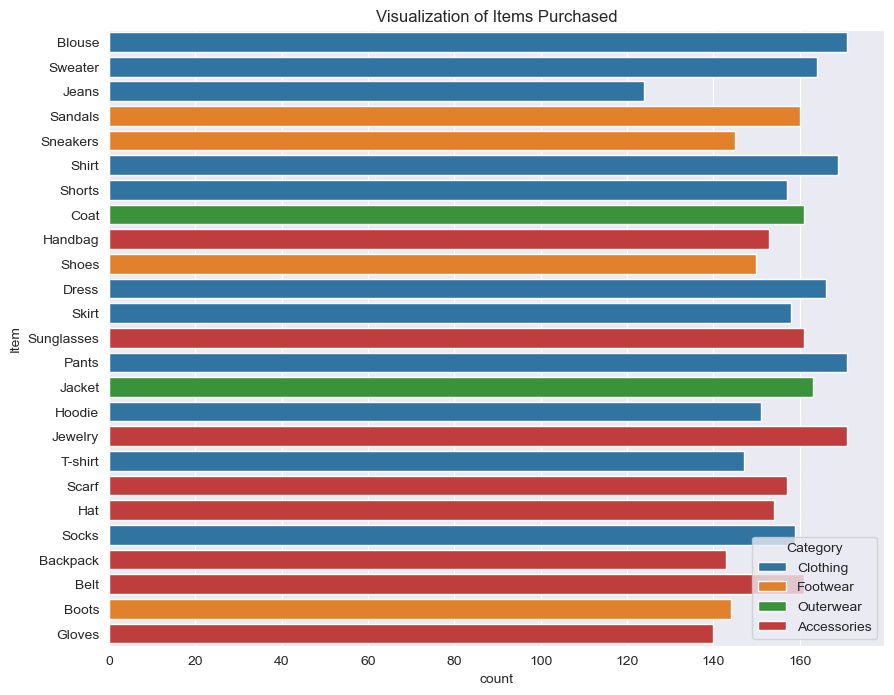

In [15]:
plt.figure(figsize = (10,8))
sns.set_style('darkgrid')
sns.countplot (y= 'Item', hue = 'Category', data= df)
plt.title('Visualization of Items Purchased')
plt.show()

__Note__: Blouse, Jewelry, and Pants are the most sold products

In [16]:
df.groupby('Category')['Item'].count().reset_index().sort_values(by = 'Item',ascending = False)

,Category,Item
1,Clothing,1737
0,Accessories,1240
2,Footwear,599
3,Outerwear,324


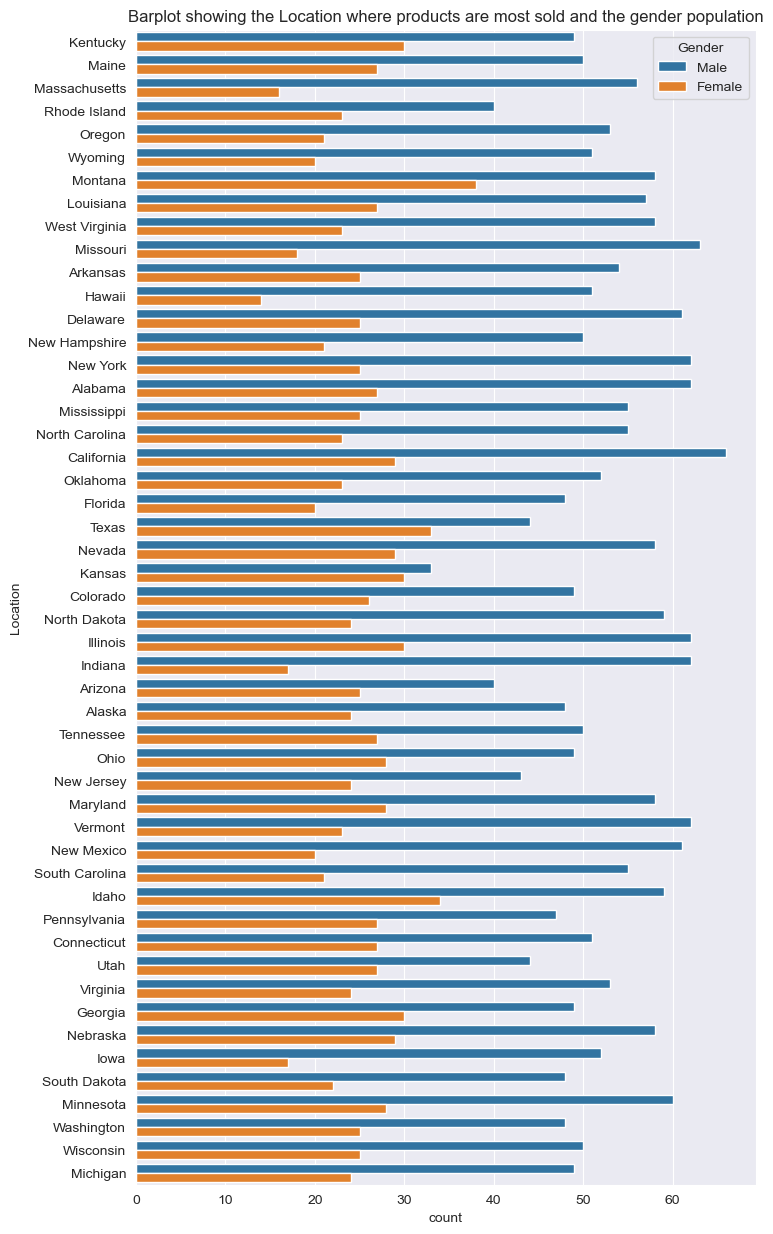

In [17]:
plt.figure(figsize = (8,15))
sns.set_style('darkgrid')
sns.countplot(y = 'Location', hue ='Gender', data = df)
plt.title('Barplot showing the Location where products are most sold and the gender population')
plt.show()

##### Note: Male customers dominated the whole locations and customers from Montana purchased most products

#### __Seasonality__

In [18]:
df.groupby('Season')['Purchase Amount (USD)'].sum().reset_index().sort_values(by = 'Purchase Amount (USD)', ascending = False)

,Season,Purchase Amount (USD)
0,Fall,60018
1,Spring,58679
3,Winter,58607
2,Summer,55777


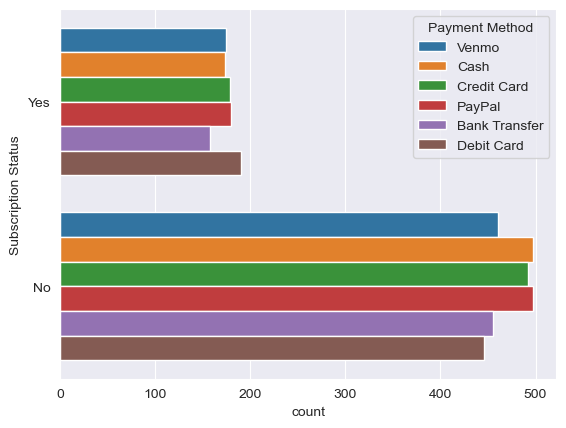

In [19]:
sns.set_style('darkgrid')
sns.countplot(y = 'Subscription Status', hue = 'Payment Method', data = df)
plt.show()

In [20]:
df['Payment Method'].value_counts()

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

#### Note
- Paypal and Credit Card are the mostly used payment method
- For customers who subscribed, they mostly used Debit Card for payment

In [21]:
selected_cols = ['Promo Code Used', 'Discount Applied', 'Frequency of Purchases']
for col in selected_cols:
    print(f'Distribution of {col}')
    print(df[col].value_counts().sort_values(ascending = False))
    print()

Distribution of Promo Code Used
Promo Code Used
No     2223
Yes    1677
Name: count, dtype: int64

Distribution of Discount Applied
Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

Distribution of Frequency of Purchases
Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64



#### __Bivariate Analysis__

In [22]:
df.sample(1)

,Customer ID,Age,Gender,Item,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
2530,2531,25,Male,Skirt,Clothing,98,Massachusetts,S,Cyan,Spring,3.6,No,Free Shipping,No,No,28,Debit Card,Weekly


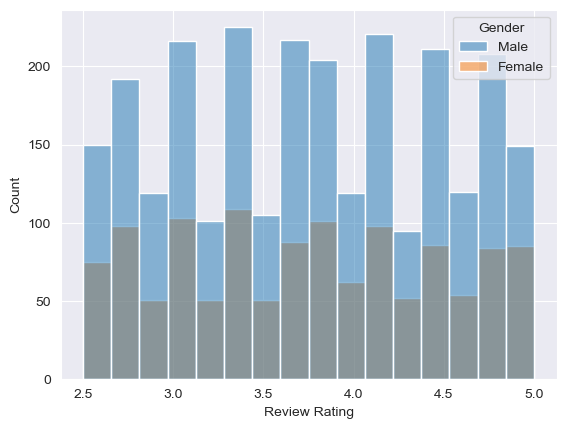

In [23]:
sns.set_style('darkgrid')
sns.histplot(x = 'Review Rating', hue = 'Gender',data =df)
plt.show()

In [24]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


#### Creating Age and Rating Classes

In [25]:
def age_func(a):
    b =''   
    if a in range(15,26):
        b= '15-25'
    elif a in range(26,36):
        b = '26-35'
    elif a in range(36,46):
        b = '36-45'
    elif a in range(46,56):
        b = '46-55'
    elif a in range(56,66):
        b = '56-65'
    elif a in range (66,76):
        b = '66-75'
    return b

In [26]:
df['Age Range'] = df['Age'].map(age_func)

In [27]:
def rating_func (r):
    s = ''
    if r == 2.5 and r <= 3.0:
        s = '2.5-3.0'
    elif r> 3.0 and r <= 4:
        s = '3.1-4.0'
    elif r > 4 and r <= 5:
        s ='4.1-5.0'
    return s

In [28]:
df['Review Rating Range'] = df['Review Rating'].map(rating_func)

In [29]:
df_1 = df.drop(columns = ['Age','Review Rating'])

#### Relationship between age and products 

In [30]:
age_item_df = df_1.groupby(['Age Range','Item']).size().reset_index(name = 'count')
age_item_df.sample(2)

,Age Range,Item,count
75,46-55,Backpack,20
92,46-55,Shoes,43


In [31]:
for x in df_1['Age Range'].unique():
    print(f'Proudcts bought by Customers within the age range {x} are {df_1[df_1['Age Range'] == x]['Item'].nunique()}')
    print(df_1[df_1['Age Range'] == x]['Item'].unique())
    print()

Proudcts bought by Customers within the age range 46-55 are 25
['Blouse' 'Jeans' 'Sneakers' 'Shoes' 'Dress' 'Sweater' 'Handbag' 'Pants'
 'Socks' 'Jewelry' 'Coat' 'Scarf' 'Belt' 'Gloves' 'Hat' 'Skirt'
 'Sunglasses' 'Jacket' 'Boots' 'Sandals' 'Shorts' 'Shirt' 'Backpack'
 'T-shirt' 'Hoodie']

Proudcts bought by Customers within the age range 15-25 are 25
['Sweater' 'Sandals' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie' 'Coat' 'Scarf'
 'Belt' 'Dress' 'Hat' 'Shoes' 'Jeans' 'Shorts' 'Jewelry' 'Shirt'
 'Sneakers' 'T-shirt' 'Socks' 'Gloves' 'Handbag' 'Skirt' 'Boots'
 'Backpack' 'Blouse']

Proudcts bought by Customers within the age range 36-45 are 25
['Blouse' 'Jewelry' 'Jacket' 'T-shirt' 'Hat' 'Shirt' 'Backpack' 'Coat'
 'Dress' 'Scarf' 'Sweater' 'Sneakers' 'Gloves' 'Shorts' 'Sandals' 'Pants'
 'Handbag' 'Shoes' 'Belt' 'Boots' 'Sunglasses' 'Hoodie' 'Jeans' 'Socks'
 'Skirt']

Proudcts bought by Customers within the age range 56-65 are 25
['Shirt' 'Handbag' 'Coat' 'Dress' 'Skirt' 'Pants' 'Shorts' 'Jewe

In [32]:
clothing_df = df[df['Category'] == 'Clothing']

In [33]:
clothing_df.groupby(['Item','Size','Color']).size().reset_index()

,Item,Size,Color,0
0,Blouse,L,Beige,1
1,Blouse,L,Black,2
2,Blouse,L,Blue,1
3,Blouse,L,Brown,2
4,Blouse,L,Charcoal,3
...,...,...,...,...
793,T-shirt,XL,Purple,1
794,T-shirt,XL,Silver,1
795,T-shirt,XL,Turquoise,2
796,T-shirt,XL,White,1


#### Analytics

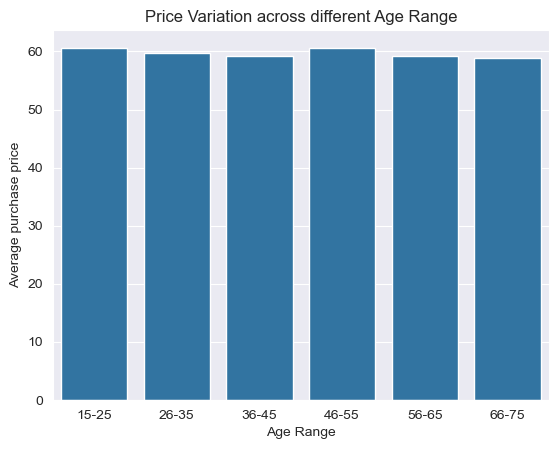

In [34]:
sns.set_style('darkgrid')
x = df_1.groupby('Age Range')['Purchase Amount (USD)'].mean().reset_index(name = 'Average purchase price')
sns.barplot(x = 'Age Range', y = 'Average purchase price', data = x)
plt.title('Price Variation across different Age Range')
plt.show()

In [35]:
df.sample(1)

,Customer ID,Age,Gender,Item,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Range,Review Rating Range
1942,1943,63,Male,Pants,Clothing,28,Alabama,M,Cyan,Fall,3.4,No,Express,No,No,22,PayPal,Monthly,56-65,3.1-4.0


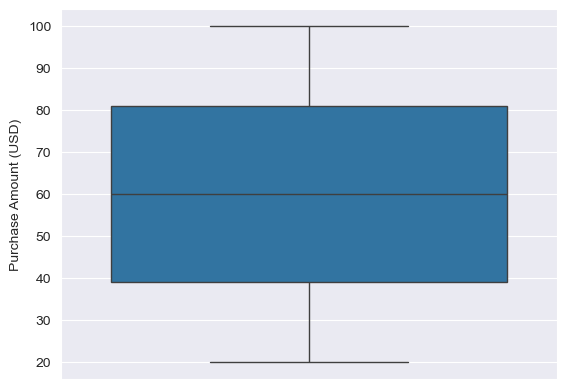

In [36]:
sns.set_style('darkgrid')
sns.boxplot( y = 'Purchase Amount (USD)', data = df)
plt.show()

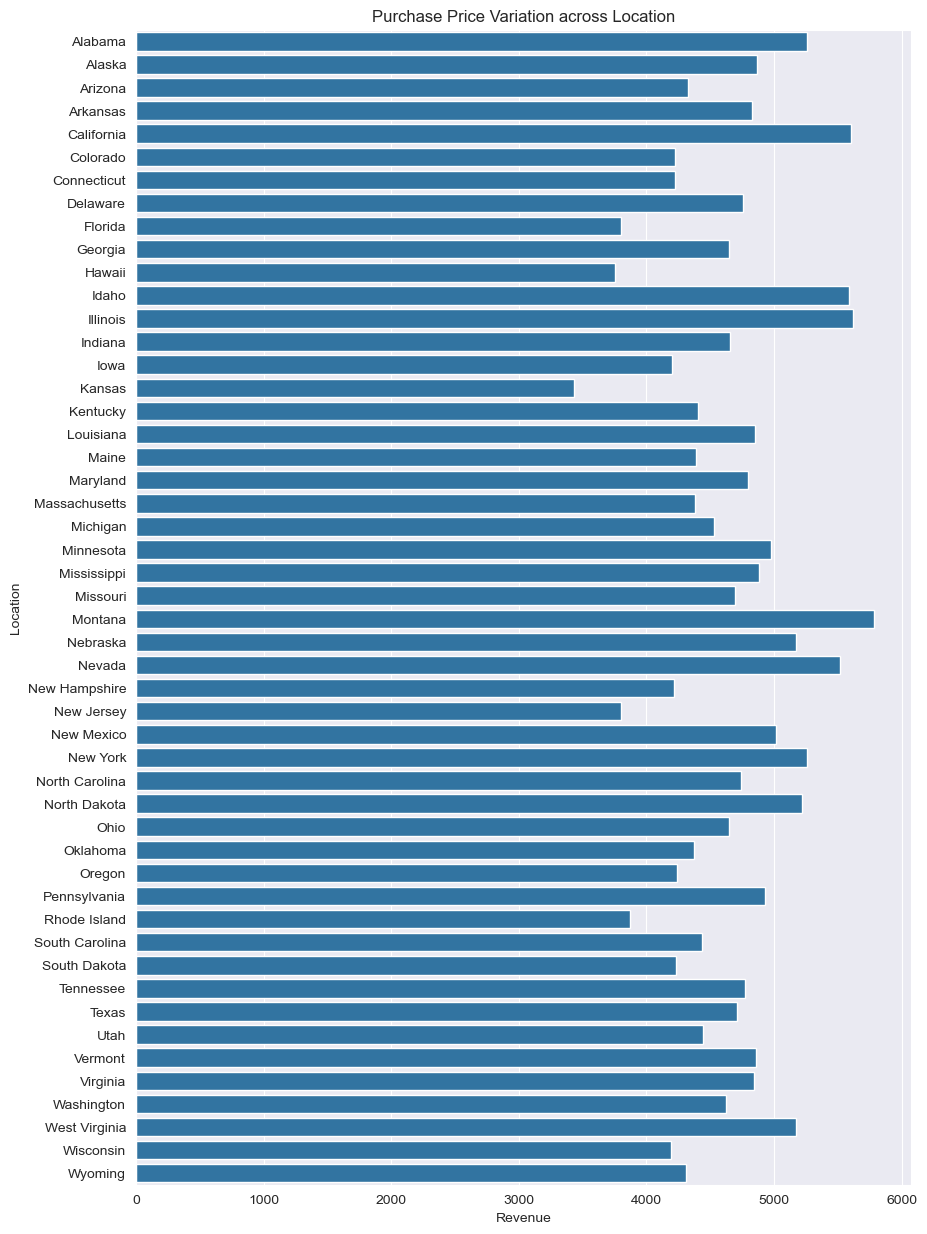

In [37]:
rev_loc = df.groupby('Location')['Purchase Amount (USD)'].sum().reset_index(name = 'Revenue')
plt.figure(figsize = (10,15))
sns.set_style('darkgrid')
sns.barplot(x='Revenue' , y ='Location', data = rev_loc)
plt.title('Purchase Price Variation across Location')
plt.show()

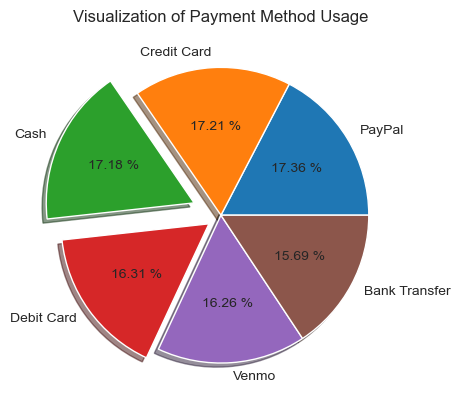

In [38]:
sns.set_style('darkgrid')
payment = df['Payment Method'].value_counts().reset_index()
def func (arg):
    return f'{arg:.2f} %'
plt.pie(x = payment['count'], labels = payment['Payment Method'], autopct = func , shadow = True, explode = [0,0,0.2,0.1,0,0,])
plt.title('Visualization of Payment Method Usage')
plt.show()

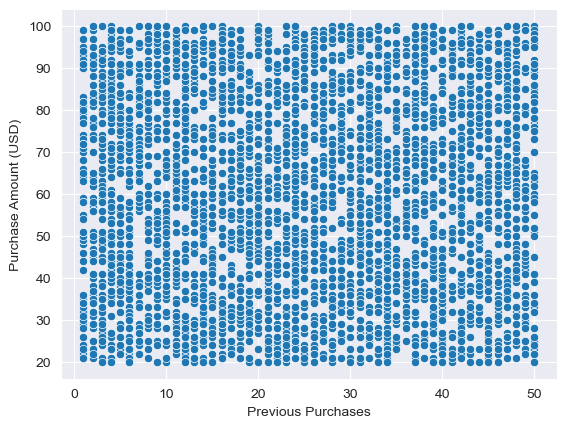

In [39]:
sns.set_style('darkgrid')
sns.scatterplot(x = 'Previous Purchases' , y = 'Purchase Amount (USD)', data = df)
plt.show()

### Unsupervised Learning

##### Encoding categorical features

In [40]:
from sklearn.preprocessing import LabelEncoder

In [41]:
age_enc = LabelEncoder()
gen_enc = LabelEncoder()
item_enc = LabelEncoder()
cat_enc = LabelEncoder()
loc_enc = LabelEncoder()
size_enc = LabelEncoder()
color_enc = LabelEncoder()
sea_enc = LabelEncoder()
rev_enc = LabelEncoder()
sub_enc = LabelEncoder()
ship_enc = LabelEncoder()
disc_enc =LabelEncoder()
promo_enc = LabelEncoder()
pay_enc = LabelEncoder()
freq_enc = LabelEncoder()

In [42]:
categorical_col = df_1.select_dtypes(include = object).columns
encoders = [age_enc, gen_enc, item_enc,cat_enc, loc_enc, size_enc, color_enc, sea_enc, rev_enc, sub_enc, ship_enc, disc_enc, promo_enc, pay_enc, freq_enc]

In [43]:
for col,encoder in zip(categorical_col, encoders):
    df_1[col] = encoder.fit_transform(df_1[col])

In [44]:
df_1.sample(1)

,Customer ID,Gender,Item,Category,Purchase Amount (USD),Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Range,Review Rating Range
3588,3589,0,22,0,55,21,1,11,1,0,0,0,0,40,1,0,0,2


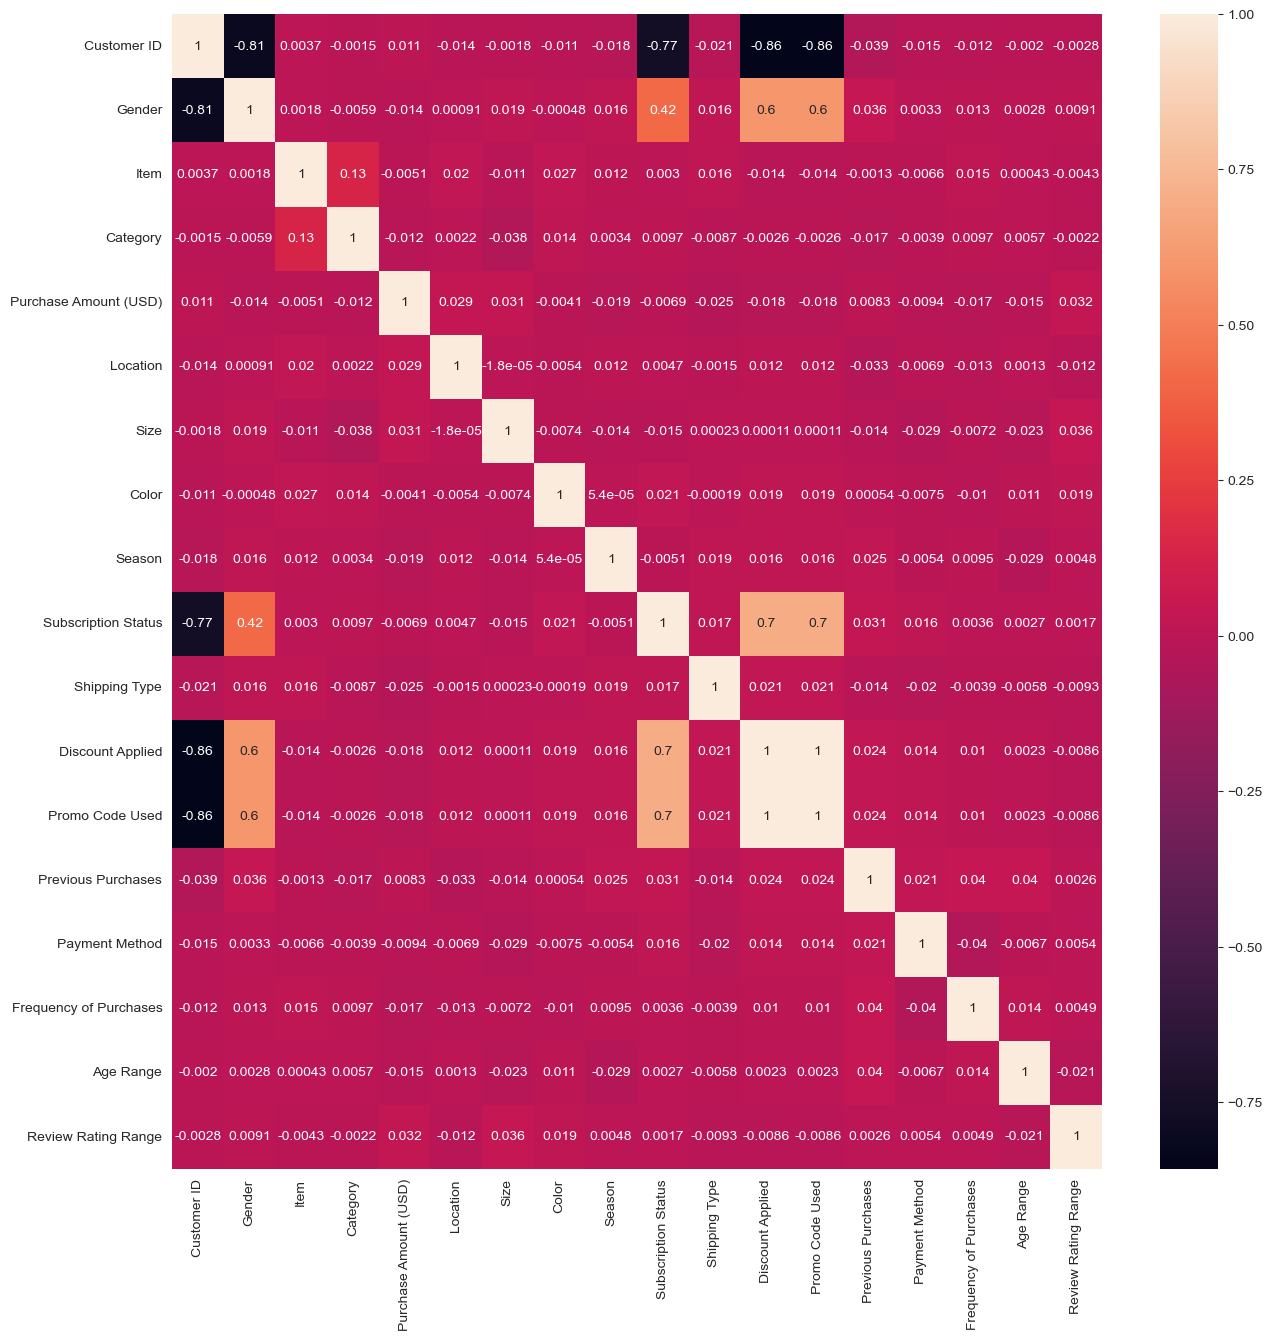

In [45]:
plt.figure(figsize = (15,15))
sns.heatmap(df_1.corr(method = 'spearman'),annot=True)
plt.show()

#### Clustering

In [46]:
from sklearn.cluster import KMeans

In [47]:
from scipy.spatial.distance import cdist

In [48]:
K = range(1,10)
inertia = []

In [49]:
distortion = []
mapping_inertia = {}

#### Finding the Optimal K using Inertia 

In [50]:
for k in K:
    kmean_model = KMeans(n_clusters = k, random_state = 42, n_init = 10 )
    kmean_model.fit(df_1)
    distortion.append(sum((np.min(cdist(df_1,kmean_model.cluster_centers_, 'euclidean'),axis =1))**2)/df_1.shape[0])
    inertia.append(kmean_model.inertia_)
    mapping_inertia[k] = inertia[-1]

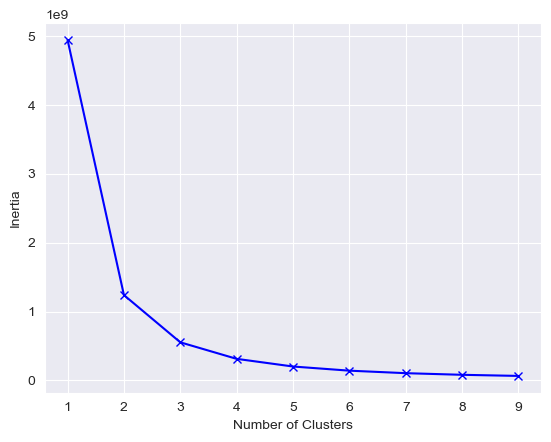

In [51]:
sns.set_style('darkgrid')
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

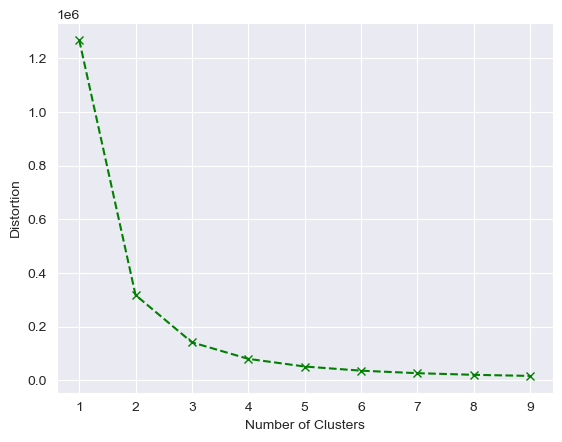

In [52]:
sns.set_style('darkgrid')
plt.plot(K,distortion, 'gx--')
plt.ylabel('Distortion')
plt.xlabel('Number of Clusters')
plt.show()

#### The optimal K is 3 so we retrain the model

In [53]:
final_kmeans= KMeans(n_clusters = 3, random_state = 42, n_init =20)
df_1['cluster'] = final_kmeans.fit_predict(df_1)

In [54]:
from sklearn.metrics import silhouette_score

In [55]:
silh_score = silhouette_score(df_1,df_1['cluster'])

In [56]:
print('Silhouette Score:',np.round(silh_score,2))

Silhouette Score: 0.59


#### __DBSCAN Algorithm__

In [57]:
X = df_1.drop(columns ='cluster')

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
X_scaled = StandardScaler().fit_transform(X)

In [60]:
min_samples = 34

##### Determining eps using a K-distance plot

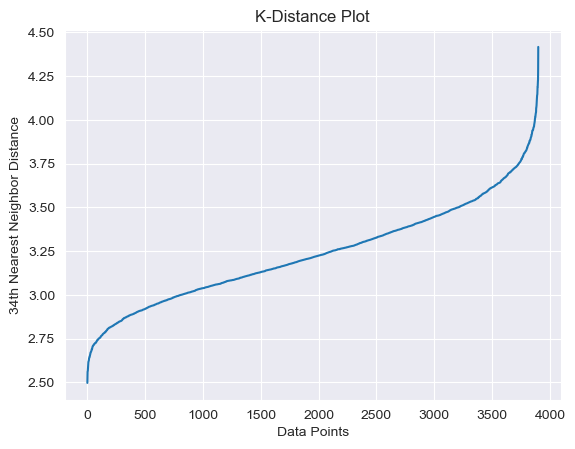

In [61]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 17

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

sns.set_style('darkgrid')
plt.plot(k_distances)
plt.xlabel("Data Points")
plt.ylabel("34th Nearest Neighbor Distance")
plt.title("K-Distance Plot")
plt.show()

In [62]:
from sklearn.cluster import DBSCAN

In [63]:
db = DBSCAN(eps =2.4, min_samples = 10).fit(X_scaled)

In [64]:
core_samples_mask = np.zeros_like(db.labels_, dtype=bool) #creates an array with the same shape as db.labels_, but filled with zeros.

In [65]:
core_samples_mask[db.core_sample_indices_] = True #This changes certain positions from False to True.

In [66]:
np.unique(db.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6], dtype=int64)

['y', 'b', 'g', 'r', 'c', 'm']


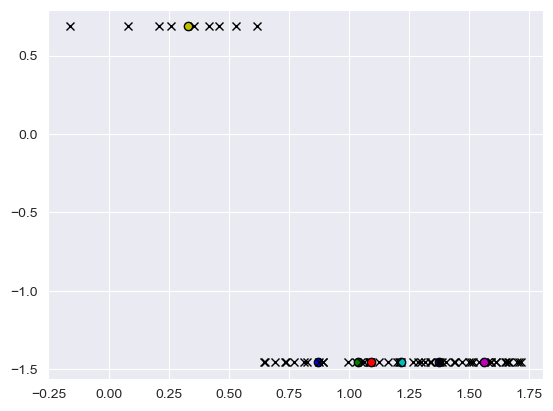

In [67]:
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
unique_labels = set(labels)

colors = ['y','b','g','r','c','m']
print(colors)

for k, col in zip(unique_labels, colors):
    if k == -1 :
        col = 'k' #k represents black in matplotlib
    class_member_mask = (labels == k)
    
    '''This line selects points that satisfy two conditions:
            - They belong to the current cluster.
            - They are core points.'''
    
    xy = X_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',markersize=6)
    
    '''Give me points belonging to this cluster that are NOT core points.'''
    xy = X_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'x', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)


In [68]:
sc = silhouette_score(X_scaled, labels)
print(f'Silhouette Coefficeint: {round(sc,2)}')

Silhouette Coefficeint: -0.17


Note: The Algorithm wasn't good for the data

#### OPTICS Algorithm

In [69]:
from sklearn.cluster import OPTICS

X_optics = df_1.drop(columns = 'cluster')

clustering = OPTICS(min_samples= 34, xi=0.05, min_cluster_size=0.05)
clustering.fit(X_optics)

labels = clustering.labels_

In [70]:
np.unique(labels)

array([0])

#### Note
The OPTICS algorithm also didn't perform well on the data.

### Agglomerative Clustering

In [71]:
ag_data = df_1.drop(columns = 'cluster')

from sklearn.cluster import AgglomerativeClustering

In [72]:
ac_model = AgglomerativeClustering(n_clusters = 4, linkage = 'average')

In [73]:
labels = ac_model.fit_predict(ag_data)

'''check the clusters'''
print('Unique Labels:',  np.unique(labels))

'''count the number of observations in each cluster'''
print("Cluster Counts:", np.bincount(labels))

'''Calculate Silhouette SCore'''
score = print('Silhouette Score:', round(silhouette_score(ag_data, labels),2))

Unique Labels: [0 1 2 3]
Cluster Counts: [1374 1008  886  632]
Silhouette Score: 0.53


### Cluster Summary

In [74]:
df_1.sample(2)

,Customer ID,Gender,Item,Category,Purchase Amount (USD),Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Range,Review Rating Range,cluster
1183,1184,1,13,1,39,17,1,24,1,0,0,1,1,4,2,6,0,3,0
2954,2955,0,24,1,28,40,1,9,3,0,1,0,0,15,2,0,1,2,1


#### Decoding the encoded features in other to perform further analysis

In [75]:
for col,encoder in zip(categorical_col, encoders):
    df_1[col] = encoder.inverse_transform(df_1[col])

In [76]:
df_1.head(2)

,Customer ID,Gender,Item,Category,Purchase Amount (USD),Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Range,Review Rating Range,cluster
0,1,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,46-55,3.1-4.0,0
1,2,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,Yes,Express,Yes,Yes,2,Cash,Fortnightly,15-25,3.1-4.0,0


In [77]:
df = df.drop(columns = ['Age Range', 'Review Rating Range'])

In [78]:
df = df.merge(df_1).drop(columns = ['Age Range', 'Review Rating Range'])

#### Profiling Each Cluster 

In [79]:
df.sample(2)

,Customer ID,Age,Gender,Item,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,cluster
1703,1704,39,Male,Backpack,Accessories,22,California,M,Black,Spring,4.0,No,Next Day Air,No,No,12,Bank Transfer,Annually,2
3338,3339,29,Female,Skirt,Clothing,94,Minnesota,L,White,Winter,2.9,No,2-Day Shipping,No,No,46,Credit Card,Monthly,1


In [80]:
for cluster in sorted(df['cluster'].unique()):
    print(f'\nCluster {cluster}')
    print(df[df['cluster'] == cluster]['Category'].value_counts().head())
    print(df[df['cluster'] == cluster]['Frequency of Purchases'].value_counts().head())
    print(df[df['cluster'] == cluster]['Subscription Status'].value_counts())
    print()


Cluster 0
Category
Clothing       571
Accessories    410
Footwear       203
Outerwear      112
Name: count, dtype: int64
Frequency of Purchases
Every 3 Months    199
Annually          191
Fortnightly       190
Weekly            189
Monthly           180
Name: count, dtype: int64
Subscription Status
Yes    1053
No      243
Name: count, dtype: int64


Cluster 1
Category
Clothing       581
Accessories    409
Footwear       207
Outerwear      107
Name: count, dtype: int64
Frequency of Purchases
Annually          201
Bi-Weekly         196
Every 3 Months    193
Monthly           191
Quarterly         177
Name: count, dtype: int64
Subscription Status
No    1304
Name: count, dtype: int64


Cluster 2
Category
Clothing       585
Accessories    421
Footwear       189
Outerwear      105
Name: count, dtype: int64
Frequency of Purchases
Quarterly         211
Every 3 Months    192
Fortnightly       182
Monthly           182
Annually          180
Name: count, dtype: int64
Subscription Status
No    13

In [81]:
df.groupby("cluster").agg({
    "Purchase Amount (USD)": ["mean", "median", "min", "max"],
    "Previous Purchases": ["mean", "median", "min", "max"],
})

Purchase Amount (USD)                 Previous Purchases             \
                         mean median min  max               mean median min   
cluster                                                                       
0                   59.853395   60.0  20  100          26.146605   26.0   1   
1                   60.255368   60.0  20  100          24.625000   24.0   1   
2                   59.183077   59.0  20  100          25.287692   25.0   1   

             
        max  
cluster      
0        50  
1        50  
2        50

In [82]:
df.groupby("cluster").agg({
    "Purchase Amount (USD)": "mean",
    "Previous Purchases": "mean"
})

,Purchase Amount (USD),Previous Purchases
cluster,,
0,59.853395,26.146605
1,60.255368,24.625000
2,59.183077,25.287692


In [83]:
for col in [
    "Gender",
    "Item",
    "Location",
    "Size",
    "Color",
    "Season",
    "Discount Applied",
    "Promo Code Used",
    "Payment Method",
    "Frequency of Purchases",
]:
    print("\n==============================")
    print(col)
    print("==============================")
    print(pd.crosstab(df["cluster"], df[col], normalize="index").round(3) * 100)


Gender
Gender   Female   Male
cluster               
0           0.0  100.0
1          95.7    4.3
2           0.0  100.0

Item
Item     Backpack  Belt  Blouse  Boots  Coat  Dress  Gloves  Handbag  Hat  \
cluster                                                                     
0             3.7   3.9     2.8    4.0   4.9    4.5     3.5      3.7  4.6   
1             3.1   4.4     5.2    3.8   3.7    4.2     3.1      4.5  4.0   
2             4.2   4.2     5.2    3.2   3.8    4.1     4.2      3.5  3.2   

Item     Hoodie  ...  Scarf  Shirt  Shoes  Shorts  Skirt  Sneakers  Socks  \
cluster          ...                                                        
0           4.4  ...    4.0    4.6    3.9     4.0    3.7       4.1    3.2   
1           4.1  ...    3.7    4.8    4.1     3.8    4.1       3.3    4.5   
2           3.1  ...    4.4    3.7    3.6     4.3    4.4       3.8    4.5   

Item     Sunglasses  Sweater  T-shirt  
cluster                                
0               3.8

| Feature                 | Cluster 0                        | Cluster 1                              | Cluster 2                            |
| ----------------------- | -------------------------------- | -------------------------------------- | ------------------------------------ |
| **Suggested name**      | **Subscribed Discount Shoppers** | **Non-Subscribed Full-Price Shoppers** | **Non-Subscribed Discount Shoppers** |
| Gender                  | 100% Male                        | 95.7% Female                           | 100% Male                            |
| Avg. Purchase Amount    | $59.85                           | $60.26                                 | $59.18                               |
| Avg. Previous Purchases | 26.15                            | 24.63                                  | 25.29                                |
| Subscription            | 81.3% Yes                        | 0% Yes                                 | 0% Yes                               |
| Discount                | 100% Yes                         | 0% Yes                                 | 29.3% Yes                            |
| Promo Code              | 100% Yes                         | 0% Yes                                 | 29.3% Yes                            |
| Main Category           | Clothing                         | Clothing                               | Clothing                             |
| Main Size               | Medium (44.8%)                   | Medium (47.2%)                         | Medium (43.0%)                       |
| Frequency pattern       | Relatively balanced              | Relatively balanced                    | Slightly more Quarterly              |


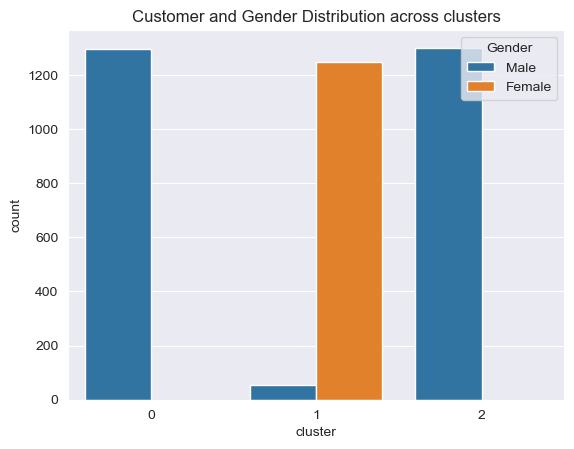

In [84]:
'''Customer Distribution and Gender Distribution across the 3 customer segment'''
sns.set_style('darkgrid')
sns.countplot(x = 'cluster', hue = 'Gender', data=df)
plt.title('Customer and Gender Distribution across clusters')
plt.show()

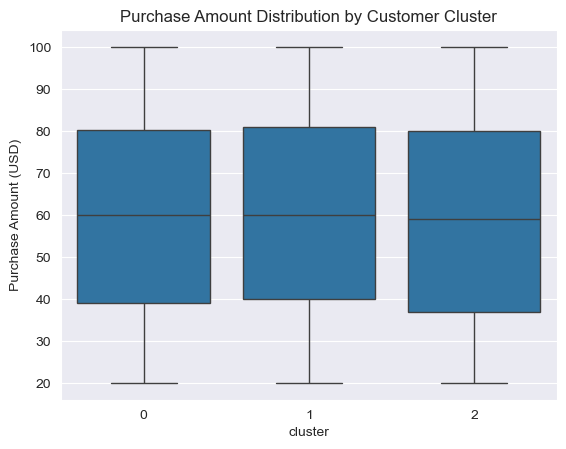

In [85]:
'''Spending Behaviour'''
sns.set_style('darkgrid')
sns.boxplot(data =df, x ='cluster', y= 'Purchase Amount (USD)')
plt.title('Purchase Amount Distribution by Customer Cluster')
plt.show()

In [86]:
cluster_names = {
    0: "Subscribed Discount Shoppers",
    1: "Non-Subscribed Full-Price Shoppers",
    2: "Non-Subscribed Discount Shoppers"
}

df["Customer Segment"] = df["cluster"].map(cluster_names)